<center>
    <h1 style="
        background-color: #1f6f5f;
        color: #f8fafc;
        padding: 10px;
        font-size: 30px;
        border-radius: 10px;
        box-shadow: 0 2px 8px rgba(0,0,0,0.15);
    ">
        <strong>Computational Intelligence For Optimization 2025/2026 - Genetic Algorithm</strong>
    </h1>
</center>

**Student ID's:**

Andreea Roica: 20250361

Carlos Amorim: 20211548

Libero Biagi: 20250349

Oliver Kain: 20250401

In this notebook, we will implement a Genetic Algorithm (including custom selection, crossover and mutation functions) to approximate an image using a triangle-based representation.

<h1 style="
    background-color: rgba(46, 125, 50, 0.55);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> Index </strong>
</h1>

[1. **Imports**](#imports)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[1.1 **Import Image**](#import-image)<br>

[2. **Utility Functions**](#utility-functions)<br>

[3. **First Run**](#first-run)<br>

[4. **Evolutionary Functions**](#evolutionary-functions)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[4.1 **Selection**](#selection)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[4.2 **Mutation**](#mutation)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[4.3 **Crossover**](#crossover)<br>

[5. **Evolutionary Algorithm**](#evolutionary-algorithm)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[5.1 **Fitness Evaluation Plot**](#fitness-evaluation-plot)<br>

<h1 style="
    background-color: rgba(56, 142, 60, 0.45);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> 1. Imports </strong>
</h1>

In [3]:
from PIL import Image, ImageDraw
import numpy as np
import random
from scipy.ndimage import gaussian_filter
import pandas as pd
import matplotlib.pyplot as plt
import copy

### 1.1. Import image

In [4]:
# Load the image from file
img = Image.open("girl_pearl_earing.png").convert("RGB")

# Convert the image into a NumPy array
picture = np.array(img)

# Print the shape of the array
print(picture.shape)

h, w, _ = picture.shape

(400, 300, 3)


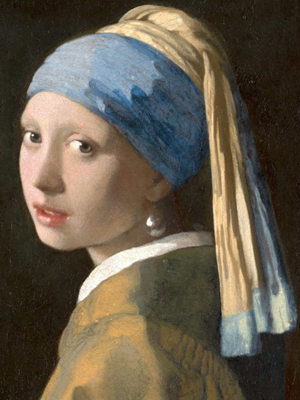

In [5]:
display(img)

As we can see, our image is "Girl with a Pearl Earring" (1865, original name "Meisje met de parel") by Johannes Vermeer (1632-1675). 

<h1 style="
    background-color: rgba(56, 142, 60, 0.45);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> 2. Utility Functions </strong>
</h1>

In [8]:
def generate_initial_population(pop_size, n_triangles, img_w, img_h):
    """
    Creates the initial GA population of triangle-based images.

    Each individual is a list of triangles (points + RGB color).
    Triangles are placed based on coverage probability:
    less-covered regions are more likely to receive new triangles.

    Triangle colors are chosen randomly.

    Parameters
    ----------
    pop_size : int
        Number of individuals in the population.
    n_triangles : int
        Number of triangles per individual.
    img_w, img_h : int
        Image dimensions.

    Returns
    -------
    list
        Population of individuals (list of triangle dictionaries).
    """

    # Triangle size settings during initialization.
    # DX controls how far the triangle corners can move away from the base point.
    # 0.55 means up to 55% of the image width/height at the beginning.
    # 0.05 means up to 5% of the image width/height at the end.
    DX_START = 0.55
    DX_END = 0.05

    # Minimum triangle area settings.
    # AREA_START = 0.04 means early triangles must cover at least 4% of the image area.
    # AREA_END = 0.001 means later triangles only need to cover at least 0.1%.
    AREA_START = 0.04
    AREA_END = 0.001

    population = []

    for i in range(pop_size):

        individual = []

        # Start with a blank canvas for each individual.
        canvas_img = Image.new(
            "RGB",
            (img_w, img_h),
            (255, 255, 255)
        )

        # Tracks how often pixels are already covered.
        coverage_map = np.zeros((img_h, img_w), dtype=float)

        for step in range(n_triangles):

            points = random_triangle(
                step=step,
                max_steps=max(1, n_triangles - 1),
                img_w=img_w,
                img_h=img_h,
                dx_start=DX_START,
                dx_end=DX_END,
                area_start=AREA_START,
                area_end=AREA_END,
                coverage_map=coverage_map
            )

            # Use a random RGB color.
            color = tuple(np.random.randint(0, 256, size=3))

            triangle = {
                "points": points,
                "color": color
            }

            individual.append(triangle)

            # Update the canvas.
            draw_triangle(canvas_img, points, color)

            # Update coverage map.
            mask = Image.new("L", (img_w, img_h), 0)

            ImageDraw.Draw(mask).polygon(
                points,
                fill=1
            )

            coverage_map += np.asarray(mask)

        population.append(individual)

    return population


def render_and_fitness(individual, target_arr, img_w, img_h):
    """
    Renders an individual and computes RMSE fitness.

    Parameters
    ----------
    individual : list
        List of triangles (dict with 'points' and 'color').
    target_arr : np.ndarray
        Target image array.
    img_w, img_h : int
        Image dimensions.

    Returns
    -------
    PIL.Image
        Rendered image.
    float
        RMSE fitness (lower is better).
    """

    canvas = Image.new("RGB", (img_w, img_h), (0, 0, 0))
    draw = ImageDraw.Draw(canvas)

    # Draw all triangles of the individual.
    for triangle in individual:
        draw.polygon(triangle["points"], fill=triangle["color"])

    # Compare the rendered image with the target image.
    gen_arr = np.asarray(canvas, dtype=float)
    rmse = np.sqrt(np.mean((target_arr - gen_arr) ** 2))

    return canvas, rmse


def triangle_area(triangle):
    """
    Computes area of a triangle using the Shoelace formula.

    Parameters
    ----------
    triangle : list
        Three (x, y) points.

    Returns
    -------
    float
        Triangle area.
    """

    (x1, y1), (x2, y2), (x3, y3) = triangle

    return abs(
        x1 * (y2 - y3)
        + x2 * (y3 - y1)
        + x3 * (y1 - y2)
    ) / 2


def draw_triangle(img, triangle, color):
    """
    Draws a filled triangle on an image.

    Parameters
    ----------
    img : PIL.Image
    triangle : list
        List of (x, y) points.
    color : tuple
        RGB color.
    """

    draw = ImageDraw.Draw(img)
    draw.polygon(triangle, fill=color)


def random_triangle(
    step,
    max_steps,
    img_w,
    img_h,
    dx_start,
    dx_end,
    area_start,
    area_end,
    coverage_map
):
    """
    Generates a triangle biased toward less-covered regions.

    Parameters
    ----------
    step : int
        Current step in initialization.
    max_steps : int
        Total number of initialization steps.
    img_w, img_h : int
        Image dimensions.
    dx_start, dx_end : float
        Controls triangle size range over time.
    area_start, area_end : float
        Controls minimum triangle area over time.
    coverage_map : np.ndarray
        Tracks how often pixels are already covered.

    Returns
    -------
    list
        Triangle defined by 3 (x, y) points.
    """

    # Progress from 0 to 1 during initialization.
    progress = step / max(1, max_steps)

    # Triangle size becomes smaller over time.
    dx_scale = np.interp(progress, [0, 1], [dx_start, dx_end])
    area_scale = np.interp(progress, [0, 1], [area_start, area_end])

    max_dx = max(1, int(img_w * dx_scale))
    max_dy = max(1, int(img_h * dx_scale))

    min_area = img_w * img_h * area_scale

    # Less-covered pixels receive higher probability.
    probabilities = 1.0 / (coverage_map + 1.0)

    probabilities = probabilities.flatten()

    # Fallback in case of invalid probabilities.
    if probabilities.sum() == 0:
        probabilities = np.ones(img_w * img_h, dtype=float)

    probabilities /= probabilities.sum()

    # Sample a base point from less-covered regions.
    index = np.random.choice(img_w * img_h, p=probabilities)

    base_y, base_x = divmod(index, img_w)

    best_triangle = None

    # Try several candidate triangles.
    for _ in range(100):

        triangle = [
            (base_x, base_y),

            (
                int(np.clip(
                    base_x + np.random.randint(-max_dx, max_dx + 1),
                    0,
                    img_w - 1
                )),
                int(np.clip(
                    base_y + np.random.randint(-max_dy, max_dy + 1),
                    0,
                    img_h - 1
                ))
            ),

            (
                int(np.clip(
                    base_x + np.random.randint(-max_dx, max_dx + 1),
                    0,
                    img_w - 1
                )),
                int(np.clip(
                    base_y + np.random.randint(-max_dy, max_dy + 1),
                    0,
                    img_h - 1
                ))
            )
        ]

        best_triangle = triangle

        # Stop early if the triangle is large enough.
        if triangle_area(triangle) >= min_area:
            break
        # Always return a triangle.
    return best_triangle

<h1 style="
    background-color: rgba(56, 142, 60, 0.45);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> 3. First Run </strong>
</h1>

We define the number of triangles per individual, as well as the number of individuals in the population. 

The target picture is also defined.

In [6]:
N_TRIANGLES = 100  #triangles for individual
POP_SIZE = 500    #individuals

target_array = picture.astype(float)

Here we build our initial population...

In [12]:
population = generate_initial_population(POP_SIZE, N_TRIANGLES, w, h)

results = []

for ind in population:
    img_rendered, score = render_and_fitness(ind, target_array, w, h)
    results.append((score, img_rendered))

results.sort(key=lambda x: x[0])
top_5 = results[:5]

...And here we see it.


Top 5 results random population:


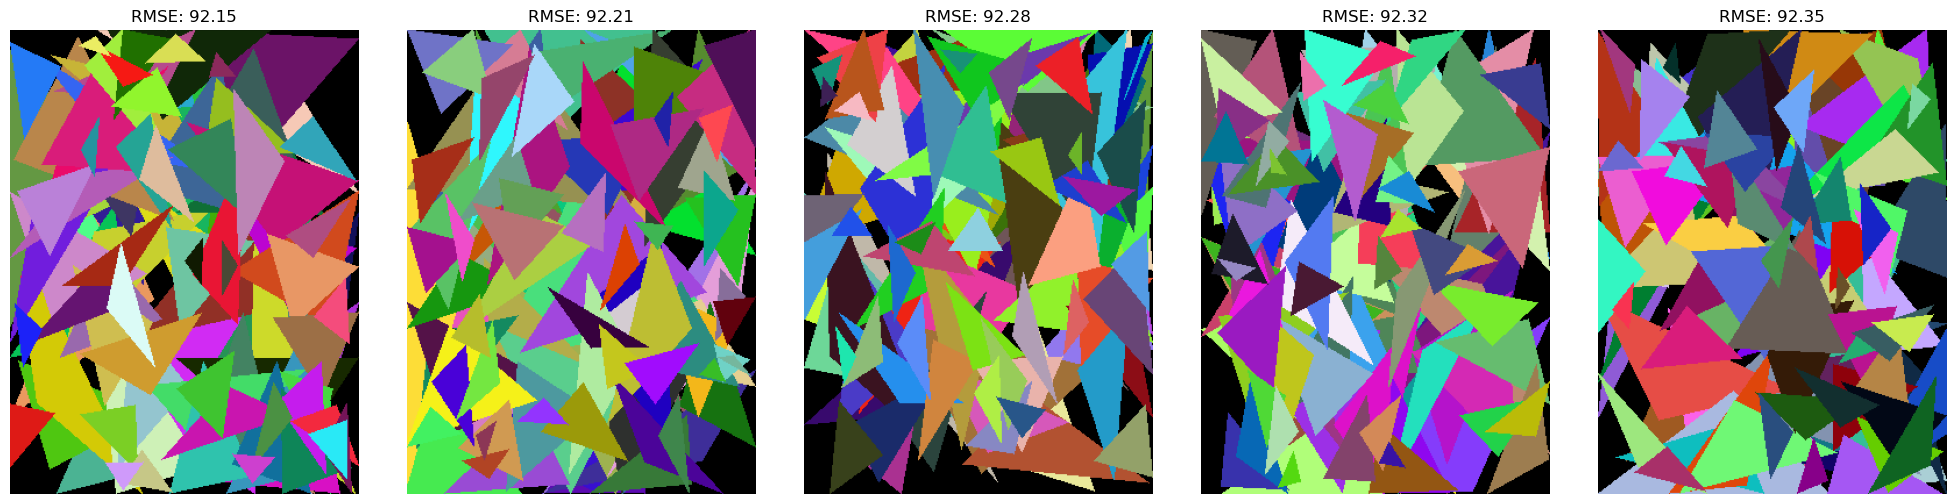

In [7]:
print("\nTop 5 results random population:")
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, (score, img_res) in enumerate(top_5):
    axes[i].imshow(img_res)
    axes[i].set_title(f"RMSE: {score:.2f}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

<h1 style="
    background-color: rgba(56, 142, 60, 0.45);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> 4. Evolutionary Functions </strong>
</h1>

### 4.1. Selection

In [13]:
def tournament_selection(population, fitness_scores, tournament_size=5):
    """
    Selects the best individual from a random subset of the population (tournament selection).

    Parameters
    ----------
    population : list
        List of individuals.
    fitness_scores : list
        Fitness value for each individual.
    tournament_size : int
        Number of individuals competing in the tournament.

    Returns
    -------
    individual
        Selected best individual from the tournament.
    float
        Fitness score of the selected individual.
    """

    # Randomly pick candidates for the tournament.
    selected_indices = random.sample(
        range(len(population)),
        tournament_size
    )

    best_index = None
    best_fitness = float("inf")
    
    # Find the best individual among sampled candidates.
    for idx in selected_indices:
        current_fitness = fitness_scores[idx]

        if current_fitness < best_fitness:
            best_fitness = current_fitness
            best_index = idx

    return population[best_index], best_fitness

#### Example tournament

In [14]:
# Extract the RMSE fitness values from the results.
# Each result contains: (rmse, canvas)
fitness_scores = [item[0] for item in results]

print("--- SELECTING PARENT 1 ---")
parent_1, fitness_1 = tournament_selection(
    population,
    fitness_scores,
    tournament_size=15
)

print("--- SELECTING PARENT 2 ---")
parent_2, fitness_2 = tournament_selection(
    population,
    fitness_scores,
    tournament_size=15
)

print(
    f"Selection complete!\n"
    f"Parent 1 RMSE: {fitness_1:.2f}\n"
    f"Parent 2 RMSE: {fitness_2:.2f}"
)

--- SELECTING PARENT 1 ---
--- SELECTING PARENT 2 ---
Selection complete!
Parent 1 RMSE: 95.62
Parent 2 RMSE: 94.19


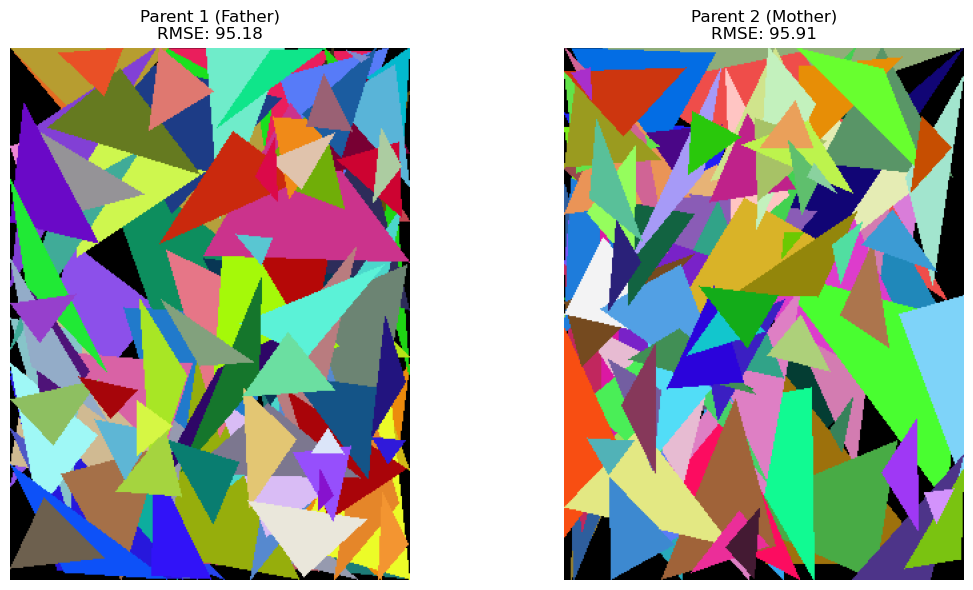

In [9]:
# 1. Render the images for both parents
# We reuse the h and w variables you defined earlier
parent_1_img, _ = render_and_fitness(parent_1, target_array, w, h)
parent_2_img, _ = render_and_fitness(parent_2, target_array, w, h)

# 2. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Show Parent 1
axes[0].imshow(parent_1_img)
axes[0].set_title(f"Parent 1 (Father)\nRMSE: {fitness_1:.2f}")
axes[0].axis('off')

# Show Parent 2
axes[1].imshow(parent_2_img)
axes[1].set_title(f"Parent 2 (Mother)\nRMSE: {fitness_2:.2f}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 4.2. Mutation

In [15]:
def get_mutation_params(generation, max_generations):
    """
    Gradually reduces mutation strength during evolution.

    Parameters
    ----------
    generation : int
        Current generation index.
    max_generations : int
        Total number of generations.

    Returns
    -------
    mutation_rate : float
        Probability of mutating each triangle.
    position_sigma : int
        Strength of positional mutation (pixel movement).
    color_sigma : int
        Strength of color mutation.
    """

    # Annealing lasts at most 700 generations.
    anneal_generations = min(max_generations, 1000)

    # Progress increases from 0 to 1 during annealing.
    progress = min(generation / anneal_generations, 1.0)

    # Reduce mutation probability over time.
    mutation_rate = np.interp(progress, [0, 1], [0.25, 0.08])

    # Reduce how far triangle points can move.
    position_sigma = int(np.interp(progress, [0, 1], [10, 2]))

    # Reduce color mutation strength.
    color_sigma = int(np.interp(progress, [0, 1], [40, 8]))

    return mutation_rate, position_sigma, color_sigma


def mutate(
    individual,
    img_w,
    img_h,
    mutation_rate=0.15,
    position_sigma=3,
    color_sigma=15
):
    """
    Mutates an individual by modifying triangle color or geometry.

    Parameters
    ----------
    individual : list
        List of triangles.
    img_w, img_h : int
        Image dimensions.
    mutation_rate : float
        Probability of mutating each triangle.
    position_sigma : int
        Maximum pixel shift for vertex mutation.
    color_sigma : int
        Maximum RGB change.

    Returns
    -------
    list
        Mutated individual.
    """

    new_individual = copy.deepcopy(individual)

    for triangle in new_individual:

        # Decide whether this triangle should mutate.
        if random.random() < mutation_rate:

            # Most mutations only change the color.
            if random.random() < 0.7:
                r, g, b = triangle["color"]

                triangle["color"] = (
                    max(0, min(255, r + np.random.randint(-color_sigma, color_sigma + 1))),
                    max(0, min(255, g + np.random.randint(-color_sigma, color_sigma + 1))),
                    max(0, min(255, b + np.random.randint(-color_sigma, color_sigma + 1)))
                )

            # Some mutations slightly move triangle vertices.
            else:
                new_coords = []

                for x, y in triangle["points"]:
                    nx = x + np.random.randint(-position_sigma, position_sigma + 1)
                    ny = y + np.random.randint(-position_sigma, position_sigma + 1)

                    # Keep points inside the image boundaries.
                    nx = max(0, min(img_w - 1, nx))
                    ny = max(0, min(img_h - 1, ny))

                    new_coords.append((nx, ny))

                triangle["points"] = new_coords
    return new_individual

#### Example mutation

In [16]:
# Create a mutated child from Parent 1
child = mutate(parent_1, w, h, mutation_rate=0.2)

# Render to see the difference
child_img, child_score = render_and_fitness(child, target_array, w, h)

print(f"Parent 1 Fitness: {fitness_1:.2f}")
print(f"Child Fitness: {child_score:.2f}")

Parent 1 Fitness: 95.62
Child Fitness: 104.70


### 4.3. Crossover

In [17]:
def crossover(parent1, parent2, img_w=400, img_h=300, grid_size=6):
    """
    Performs coverage-aware crossover between two parents.

    Ensures spatial diversity by avoiding duplicate triangles and
    encouraging coverage across different image regions.

    Parameters
    ----------
    parent1, parent2 : list
        Parent individuals (lists of triangles).
    img_w, img_h : int
        Image dimensions.
    grid_size : int
        Grid used to enforce spatial coverage.

    Returns
    -------
    list
        Child individual (list of triangles).
    """

    n = len(parent1)

    child = [None] * n

    # Track used spatial regions and duplicate triangles.
    used_cells = set()
    used_triangles = set()

    cell_w = img_w / grid_size
    cell_h = img_h / grid_size

    indices = list(range(n))
    random.shuffle(indices)

    # First pass:
    # Prefer triangles from previously unused regions.
    for i in indices:

        candidates = [parent1[i], parent2[i]]
        random.shuffle(candidates)

        for tri in candidates:

            key = (
                tuple(tri["points"]),
                tuple(tri["color"])
            )

            if key in used_triangles:
                continue

            # Compute triangle centroid to assign spatial cell.
            cx, cy = triangle_center(tri)

            cell_x = min(int(cx / cell_w), grid_size - 1)
            cell_y = min(int(cy / cell_h), grid_size - 1)

            cell = (cell_x, cell_y)

            # Accept only if region is not already used
            if cell not in used_cells:

                child[i] = tri.copy()

                used_triangles.add(key)
                used_cells.add(cell)

                break

    # Second pass:
    # Fill remaining positions using only unused triangles.
    for i in range(n):

        if child[i] is not None:
            continue

        candidates = [parent1[i], parent2[i]]
        random.shuffle(candidates)

        for tri in candidates:

            key = (
                tuple(tri["points"]),
                tuple(tri["color"])
            )

            if key not in used_triangles:

                child[i] = tri.copy()

                used_triangles.add(key)

                break

    return child


def triangle_center(tri):
    """
    Computes the centroid (geometric center) of a triangle.

    Parameters
    ----------
    tri : dict
        Triangle with "points" key containing 3 (x, y) coordinates.

    Returns
    -------
    tuple
        (x, y) centroid of the triangle.
    """

    pts = tri["points"]

    # Average of vertex coordinates.
    x = (pts[0][0] + pts[1][0] + pts[2][0]) / 3
    y = (pts[0][1] + pts[1][1] + pts[2][1]) / 3

    return x, y

#### Example crossover

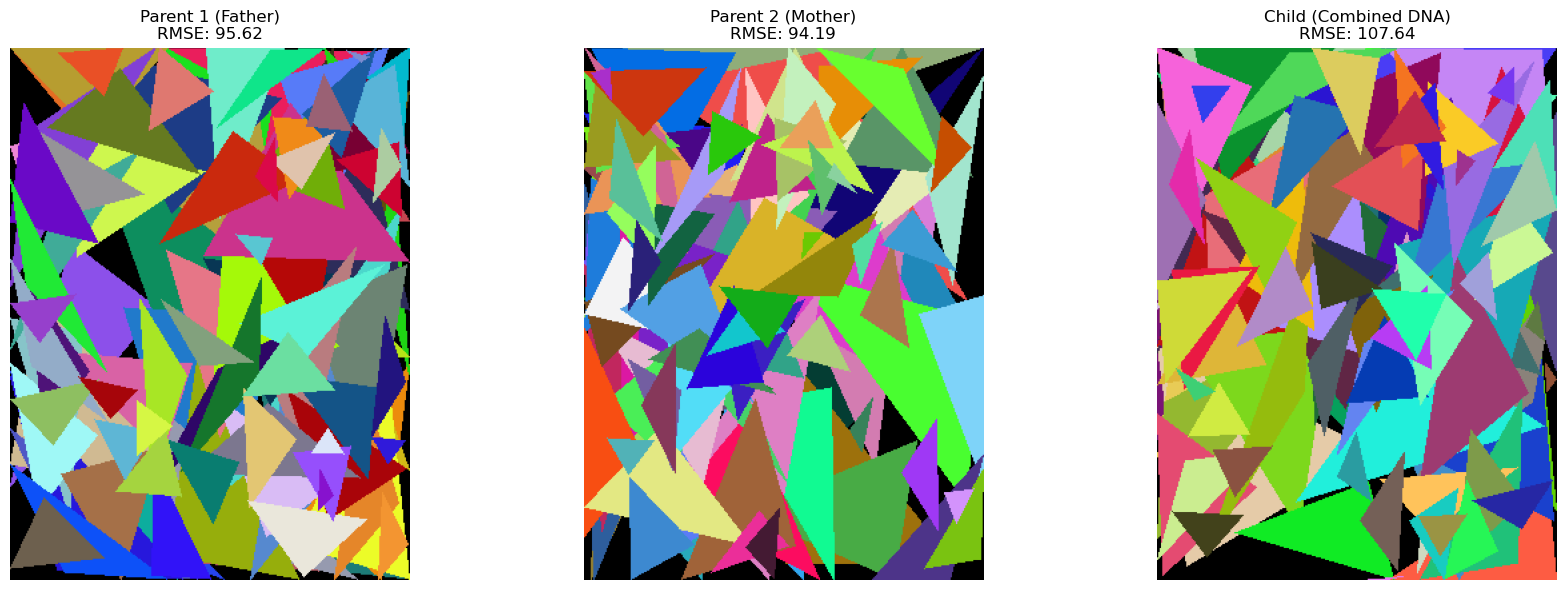

In [18]:
# 1. Generate the child
child_genotype = crossover(parent_1, parent_2)

# 2. Render the child (without mutation for now, to see pure inheritance)
child_img, child_score = render_and_fitness(child_genotype, target_array, w, h)

# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(parent_1_img)
axes[0].set_title(f"Parent 1 (Father)\nRMSE: {fitness_1:.2f}")
axes[0].axis('off')

axes[1].imshow(parent_2_img)
axes[1].set_title(f"Parent 2 (Mother)\nRMSE: {fitness_2:.2f}")
axes[1].axis('off')

axes[2].imshow(child_img)
axes[2].set_title(f"Child (Combined DNA)\nRMSE: {child_score:.2f}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

<h1 style="
    background-color: rgba(56, 142, 60, 0.45);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> 5. Evolutionary Algorithm </strong>
</h1>

In [19]:
def evolve_population(
    target_array,
    initial_pop,
    n_generations,
    tournament_size=5
):
    """
    Runs a full evolutionary algorithm over multiple generations.

    Parameters
    ----------
    target_array : np.ndarray
        Target image used for fitness evaluation.
    initial_pop : list
        Initial population of individuals.
    n_generations : int
        Number of evolutionary iterations.
    tournament_size : int
        Size of tournament used for selection.

    Returns
    -------
    current_pop : list
        Final evolved population.
    best_fitness_history : list
        Best fitness value per generation.
    """

    current_pop = copy.deepcopy(initial_pop)
    img_h, img_w, _ = target_array.shape
    best_fitness_history = []

    for gen in range(n_generations):
        # Evaluate every individual in the current population.
        evaluations = [
            render_and_fitness(individual, target_array, img_w, img_h)
            for individual in current_pop
        ]

        fitness_scores = [item[1] for item in evaluations]

        fitness_mean = np.mean(fitness_scores)
        fitness_std = np.std(fitness_scores)
        fitness_range = np.max(fitness_scores) - np.min(fitness_scores)

        # Keep the best individual unchanged.
        best_idx = np.argmin(fitness_scores)
        best_fitness = fitness_scores[best_idx]
        best_individual = current_pop[best_idx]

        best_fitness_history.append(best_fitness)

        improvement = (
            best_fitness_history[-2] - best_fitness
            if gen > 0
            else 0
        )

        print(
            f"Generation {gen + 1}/{n_generations} | "
            f"Best RMSE: {best_fitness:.4f} | "
            f"Mean: {fitness_mean:.2f} | "
            f"STD: {fitness_std:.2f} | "
            f"Range: {fitness_range:.2f} | "
            f"Delta: {improvement:.4f}"
        )

        # Use weaker mutations as evolution progresses.
        mutation_rate, position_sigma, color_sigma = get_mutation_params(
            gen,
            n_generations
        )

        # Start the next generation with the best individual.
        new_pop = [copy.deepcopy(best_individual)]

        while len(new_pop) < len(current_pop):
            parent_1, _ = tournament_selection(
                current_pop,
                fitness_scores,
                tournament_size,
            )

            parent_2, _ = tournament_selection(
                current_pop,
                fitness_scores,
                tournament_size,
            )

            child = crossover(parent_1, parent_2, img_w, img_h)

            child = mutate(
                child,
                img_w,
                img_h,
                mutation_rate=mutation_rate,
                position_sigma=position_sigma,
                color_sigma=color_sigma
            )

            new_pop.append(child)

        current_pop = new_pop

    # Final display logic remains the same...
    return current_pop, best_fitness_history

#### Example evolution

In [49]:
final_pop, history = evolve_population(
     target_array=picture, 
     initial_pop=population, 
     n_generations=3000, 
     tournament_size=10
)

Generation 1/3000 | Best RMSE: 92.1522 | Mean: 100.88 | STD: 3.44 | Range: 19.26 | Δ: 0.0000
Generation 2/3000 | Best RMSE: 88.1892 | Mean: 96.69 | STD: 2.89 | Range: 16.35 | Δ: 3.9631
Generation 3/3000 | Best RMSE: 85.3747 | Mean: 93.51 | STD: 2.64 | Range: 16.17 | Δ: 2.8144
Generation 4/3000 | Best RMSE: 82.5707 | Mean: 90.73 | STD: 2.73 | Range: 14.25 | Δ: 2.8041
Generation 5/3000 | Best RMSE: 80.2614 | Mean: 87.72 | STD: 2.63 | Range: 17.20 | Δ: 2.3093
Generation 6/3000 | Best RMSE: 78.9253 | Mean: 85.14 | STD: 2.34 | Range: 14.88 | Δ: 1.3361
Generation 7/3000 | Best RMSE: 76.2805 | Mean: 82.75 | STD: 2.31 | Range: 13.33 | Δ: 2.6448
Generation 8/3000 | Best RMSE: 76.0987 | Mean: 80.85 | STD: 2.13 | Range: 11.90 | Δ: 0.1818
Generation 9/3000 | Best RMSE: 72.2929 | Mean: 78.95 | STD: 2.16 | Range: 13.18 | Δ: 3.8058
Generation 10/3000 | Best RMSE: 70.6318 | Mean: 76.81 | STD: 2.15 | Range: 14.16 | Δ: 1.6612
Generation 11/3000 | Best RMSE: 67.8722 | Mean: 74.93 | STD: 2.18 | Range: 13.

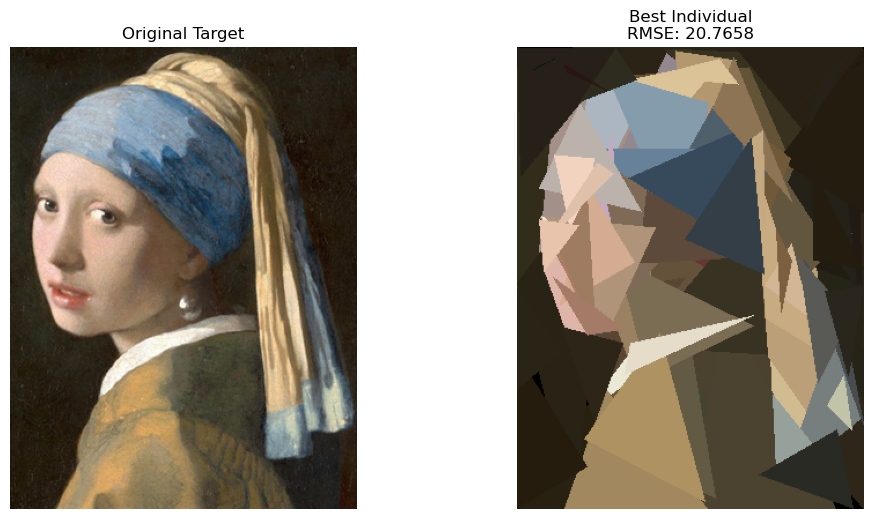

In [50]:
# 1. Evaluate the final population to find the absolute best
evaluations = [render_and_fitness(ind, picture, w, h) for ind in final_pop]
fitness_scores = [item[1] for item in evaluations]

# 2. Get the index of the best individual
best_idx = np.argmin(fitness_scores)
best_individual = final_pop[best_idx]
best_img = evaluations[best_idx][0]
best_score = fitness_scores[best_idx]

# 3. Display the results
plt.figure(figsize=(12, 6))

# Original
plt.subplot(1, 2, 1)
plt.imshow(picture)
plt.title("Original Target")
plt.axis('off')

# Best GA Result
plt.subplot(1, 2, 2)
plt.imshow(best_img)
plt.title(f"Best Individual\nRMSE: {best_score:.4f}")
plt.axis('off')

plt.show()

### 5.1. Fitness Evaluation Plot

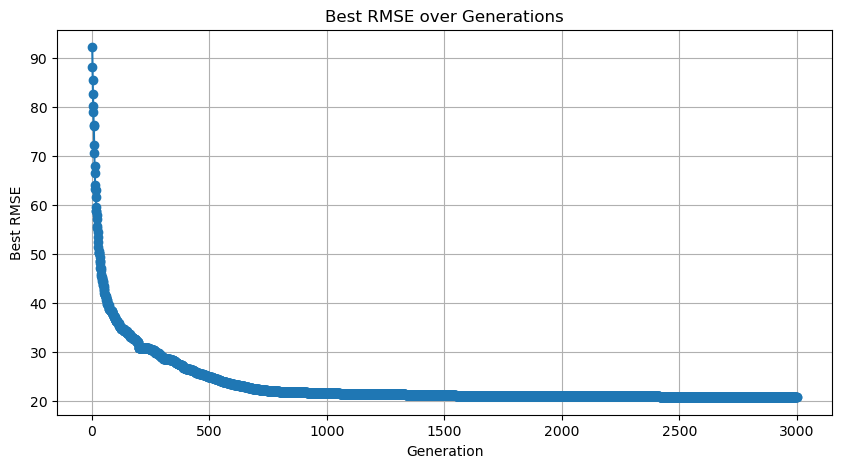

In [51]:
generations = range(1, len(history) + 1)

plt.figure(figsize=(10, 5))
plt.plot(generations, history, marker="o")
plt.xlabel("Generation")
plt.ylabel("Best RMSE")
plt.title("Best RMSE over Generations")
plt.grid(True)
plt.show()

- The RMSE drops sharply in the first ~500 generations, indicating rapid early improvement by the evolutionary algorithm, then flattens out around generation 1000.
- After ~1000 generations the best RMSE plateaus near 21, suggesting the algorithm has converged and further generations yield negligible gains.